In [13]:
import os
import cv2
import numpy as np
from numba import cuda
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [14]:
!ls /kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/

benign	malignant  normal


In [15]:
DATASET = "/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/"

images = []
labels = []

label_map = {
    "benign":0,
    "malignant":1,
    "normal":2
}

for cls in label_map:

    folder = os.path.join(DATASET, cls)

    for file in os.listdir(folder):

        if "_mask" in file:
            continue

        img = cv2.imread(
            os.path.join(folder,file),
            cv2.IMREAD_GRAYSCALE
        )

        img = cv2.resize(img,(128,128))

        images.append(img)
        labels.append(label_map[cls])

images = np.array(images,dtype=np.float32)
labels = np.array(labels)

print(images.shape)

(780, 128, 128)


In [16]:
@cuda.jit
def mean_feature_kernel(images, features):

    idx = cuda.grid(1)

    if idx < images.shape[0]:

        total = 0.0

        for i in range(images.shape[1]):
            for j in range(images.shape[2]):
                total += images[idx,i,j]

        features[idx] = total / (
            images.shape[1] * images.shape[2]
        )

In [17]:
@cuda.jit
def mean_feature_kernel(images, features):

    idx = cuda.grid(1)

    if idx < images.shape[0]:

        total = 0.0

        for i in range(images.shape[1]):
            for j in range(images.shape[2]):
                total += images[idx,i,j]

        features[idx] = total / (
            images.shape[1] * images.shape[2]
        )

In [18]:
d_images = cuda.to_device(images)

d_features = cuda.device_array(
    images.shape[0],
    dtype=np.float32
)

threads = 256
blocks = (len(images)+threads-1)//threads

mean_feature_kernel[blocks,threads](
    d_images,
    d_features
)

features = d_features.copy_to_host()

features = features.reshape(-1,1)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:748: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [19]:
X_train,X_test,y_train,y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

In [20]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train,y_train)

pred = knn.predict(X_test)

In [21]:
acc = accuracy_score(y_test,pred)

print("Accuracy =",acc)

Accuracy = 0.5064102564102564


In [22]:
test_img = cv2.imread(
    "/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (101).png",
    cv2.IMREAD_GRAYSCALE
)

test_img = cv2.resize(test_img,(128,128))

feature = np.mean(test_img).reshape(1,-1)

pred = knn.predict(feature)[0]

classes = {
    0:"Benign",
    1:"Malignant",
    2:"Normal"
}

print("Prediction:",classes[pred])

Prediction: Benign


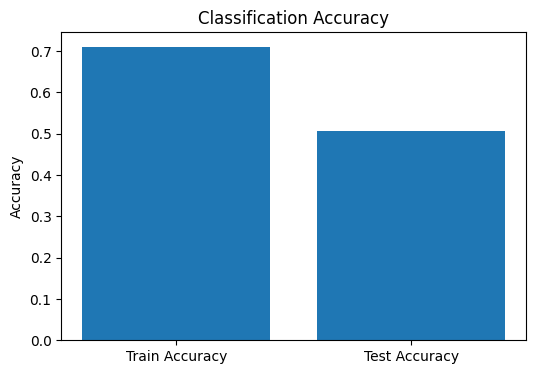

In [23]:
import matplotlib.pyplot as plt

train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)

plt.figure(figsize=(6,4))
plt.bar(
    ["Train Accuracy","Test Accuracy"],
    [train_acc,test_acc]
)
plt.ylabel("Accuracy")
plt.title("Classification Accuracy")
plt.show()

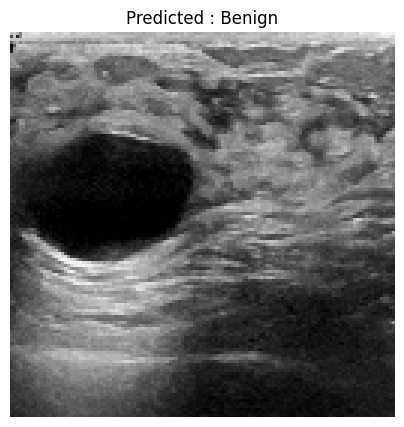

In [25]:
import matplotlib.pyplot as plt

idx = 10

img = images[idx]

feature = np.array([[np.mean(img)]])

prediction = knn.predict(feature)[0]

classes = {
    0:"Benign",
    1:"Malignant",
    2:"Normal"
}

plt.figure(figsize=(5,5))
plt.imshow(img,cmap="gray")
plt.axis("off")

plt.title(
    f"Predicted : {classes[prediction]}"
)

plt.show()

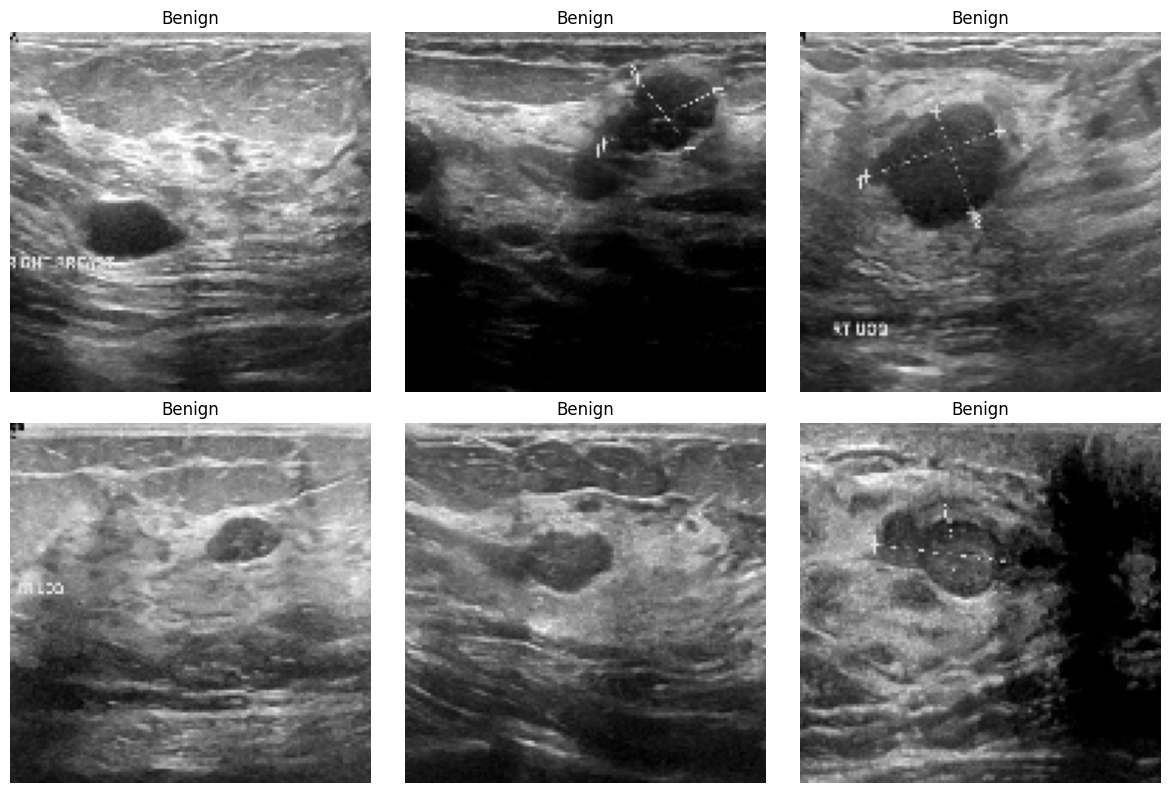

In [26]:
classes = {
    0:"Benign",
    1:"Malignant",
    2:"Normal"
}

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = images[i]

    feature = np.array([[np.mean(img)]])

    prediction = knn.predict(feature)[0]

    plt.imshow(img,cmap="gray")
    plt.axis("off")

    plt.title(classes[prediction])

plt.tight_layout()
plt.show()